# Data Analytics Project: Employability by Degree in India (Engineering, BCA, B.Sc, B.Com, B.A, MCA, MBA)

**Objective:** Compare employability across major Indian degree streams (2024-2026), using data
from the India Skills Report (Wheebox + CII + AICTE) — the standard real-world source for
degree-wise employability comparison in India.

> **Important:** India's official labour survey (PLFS) does not break unemployment down by
> specific degree (Engineering vs BCA vs B.Com vs B.A). "Employability %" here measures
> industry-assessed job-readiness, not the official unemployment rate. We also compute
> `Estimated_Skill_Gap_Percent = 100 - Employability`, a proxy for "graduates not yet
> employable" — useful for comparison, but not an official unemployment statistic.
> BCA figures are estimated since ISR does not track BCA as a standalone category.


## 1. Import Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
%matplotlib inline


## 2. Build the Dataset (India Skills Report anchors, 2024-2026)

In [10]:
rows = [
    {"Year": 2024, "Degree": "Engineering", "Employability_Percent": 64.0, "Data_Type": "Reported"},
    {"Year": 2024, "Degree": "B.Com", "Employability_Percent": 48.0, "Data_Type": "Reported"},
    {"Year": 2024, "Degree": "B.Sc", "Employability_Percent": 54.0, "Data_Type": "Estimated"},
    {"Year": 2024, "Degree": "B.A", "Employability_Percent": 50.0, "Data_Type": "Estimated"},
    {"Year": 2024, "Degree": "MBA / Management", "Employability_Percent": 75.0, "Data_Type": "Estimated"},
    {"Year": 2024, "Degree": "MCA", "Employability_Percent": 68.0, "Data_Type": "Estimated"},
    {"Year": 2024, "Degree": "BCA", "Employability_Percent": 55.0, "Data_Type": "Estimated"},

    {"Year": 2025, "Degree": "Engineering", "Employability_Percent": 71.5, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "B.Com", "Employability_Percent": 55.0, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "B.Sc", "Employability_Percent": 58.0, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "B.A", "Employability_Percent": 54.0, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "MBA / Management", "Employability_Percent": 78.0, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "MCA", "Employability_Percent": 71.0, "Data_Type": "Reported"},
    {"Year": 2025, "Degree": "BCA", "Employability_Percent": 62.0, "Data_Type": "Estimated"},

    {"Year": 2026, "Degree": "Engineering", "Employability_Percent": 80.0, "Data_Type": "Reported"},
    {"Year": 2026, "Degree": "B.Com", "Employability_Percent": 62.81, "Data_Type": "Reported"},
    {"Year": 2026, "Degree": "B.Sc", "Employability_Percent": 61.0, "Data_Type": "Reported"},
    {"Year": 2026, "Degree": "B.A", "Employability_Percent": 55.55, "Data_Type": "Reported"},
    {"Year": 2026, "Degree": "MBA / Management", "Employability_Percent": 72.76, "Data_Type": "Reported"},
    {"Year": 2026, "Degree": "MCA", "Employability_Percent": 73.0, "Data_Type": "Estimated"},
    {"Year": 2026, "Degree": "BCA", "Employability_Percent": 66.0, "Data_Type": "Estimated"},
]

df = pd.DataFrame(rows)
df["Estimated_Skill_Gap_Percent"] = (100 - df["Employability_Percent"]).round(2)
df.to_csv("india_employability_by_degree.csv", index=False)
df


,Year,Degree,Employability_Percent,Data_Type,Estimated_Skill_Gap_Percent
0,2024,Engineering,64.00,Reported,36.00
1,2024,B.Com,48.00,Reported,52.00
2,2024,B.Sc,54.00,Estimated,46.00
3,2024,B.A,50.00,Estimated,50.00
4,2024,MBA / Management,75.00,Estimated,25.00
5,2024,MCA,68.00,Estimated,32.00
6,2024,BCA,55.00,Estimated,45.00
7,2025,Engineering,71.50,Reported,28.50
8,2025,B.Com,55.00,Reported,45.00
9,2025,B.Sc,58.00,Reported,42.00


## 3. Dataset Overview

In [11]:
print('Shape:', df.shape)
print('\nDegrees:', df.Degree.unique())
print('\nYears:', df.Year.unique())
df.describe()


Shape: (21, 5)

Degrees: ['Engineering' 'B.Com' 'B.Sc' 'B.A' 'MBA / Management' 'MCA' 'BCA']

Years: [2024 2025 2026]


,Year,Employability_Percent,Estimated_Skill_Gap_Percent
count,21.00000,21.000000,21.000000
mean,2025.00000,63.553333,36.446667
std,0.83666,9.454143,9.454143
min,2024.00000,48.000000,20.000000
25%,2024.00000,55.000000,28.500000
50%,2025.00000,62.810000,37.190000
75%,2026.00000,71.500000,45.000000
max,2026.00000,80.000000,52.000000


## 4. Employability Trend by Degree (2024-2026)

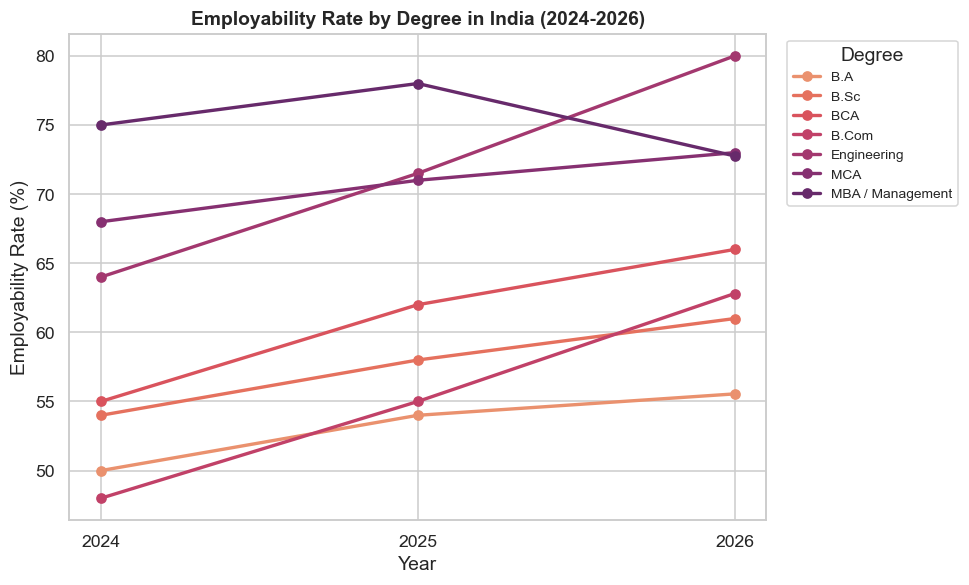

In [12]:
degree_order = ["B.A", "B.Sc", "BCA", "B.Com", "Engineering", "MCA", "MBA / Management"]
palette = sns.color_palette("flare", n_colors=len(degree_order))
deg_color = dict(zip(degree_order, palette))

plt.figure(figsize=(9, 5.5))
for deg in degree_order:
    sub = df[df.Degree == deg].sort_values("Year")
    plt.plot(sub.Year, sub.Employability_Percent, marker="o", label=deg, color=deg_color[deg], linewidth=2.2)
plt.title("Employability Rate by Degree in India (2024-2026)", fontweight="bold")
plt.ylabel("Employability Rate (%)"); plt.xlabel("Year"); plt.xticks([2024, 2025, 2026])
plt.legend(title="Degree", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()


## 5. Latest Year Comparison (2026)

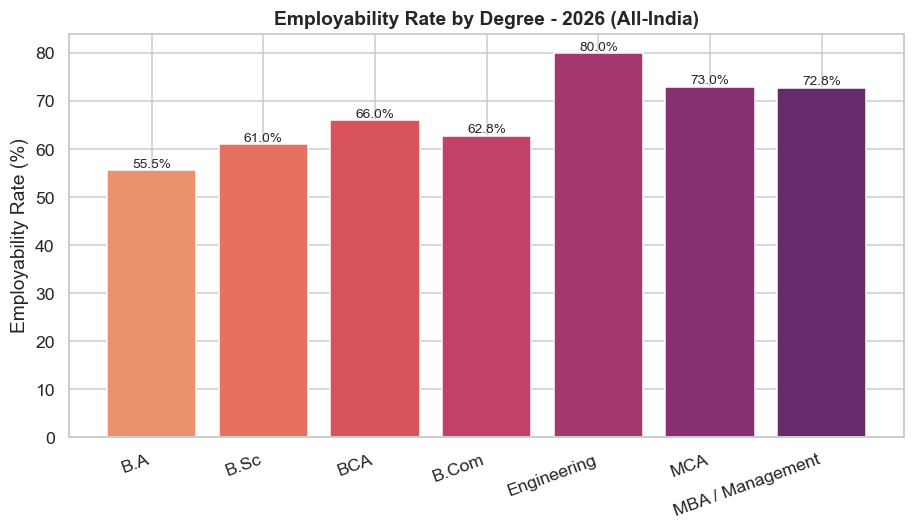

Highest: Engineering 80.0
Lowest: B.A 55.55


In [13]:
latest = df[df.Year == 2026].set_index("Degree").loc[degree_order]

plt.figure(figsize=(8.5, 5))
bars = plt.bar(latest.index, latest.Employability_Percent, color=[deg_color[d] for d in degree_order])
plt.title("Employability Rate by Degree - 2026 (All-India)", fontweight="bold")
plt.ylabel("Employability Rate (%)"); plt.xticks(rotation=20, ha="right")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.6, f"{h:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Highest:", latest.Employability_Percent.idxmax(), latest.Employability_Percent.max())
print("Lowest:", latest.Employability_Percent.idxmin(), latest.Employability_Percent.min())


## 6. Estimated Skill Gap by Degree (2026)

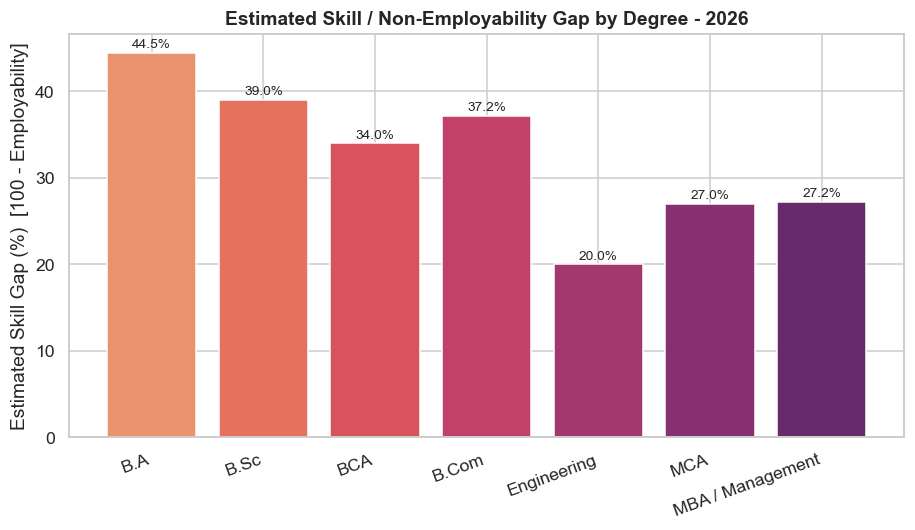

In [14]:
plt.figure(figsize=(8.5, 5))
bars = plt.bar(latest.index, latest.Estimated_Skill_Gap_Percent, color=[deg_color[d] for d in degree_order])
plt.title("Estimated Skill / Non-Employability Gap by Degree - 2026", fontweight="bold")
plt.ylabel("Estimated Skill Gap (%)  [100 - Employability]"); plt.xticks(rotation=20, ha="right")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.6, f"{h:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


## 7. Heatmap: Degree × Year

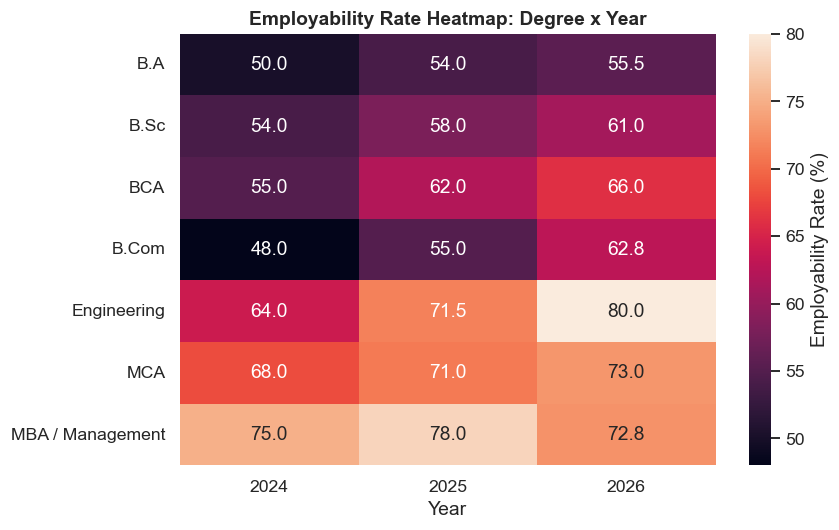

In [15]:
heat_df = df.pivot(index="Degree", columns="Year", values="Employability_Percent").loc[degree_order]

plt.figure(figsize=(8, 5))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="rocket", cbar_kws={"label": "Employability Rate (%)"})
plt.title("Employability Rate Heatmap: Degree x Year", fontweight="bold")
plt.ylabel(""); plt.xlabel("Year")
plt.tight_layout(); plt.show()


## 8. Bonus: Gender Employability Gap (All-India, Real ISR Data)

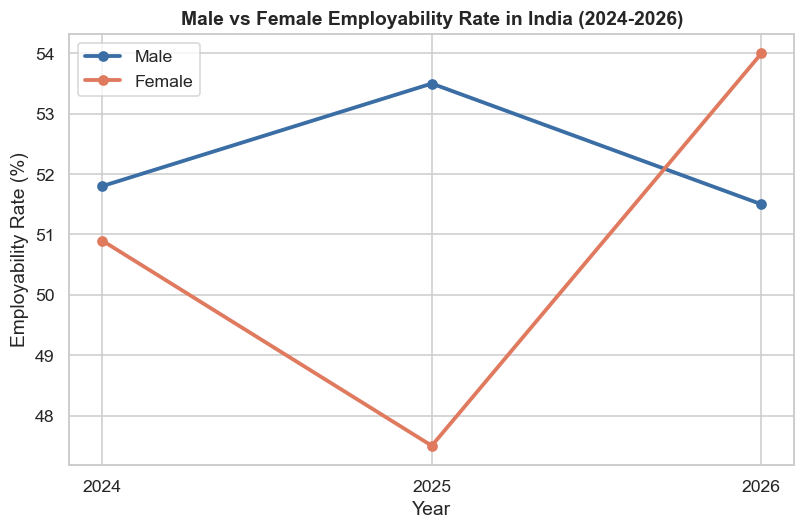

In [16]:
gender_rows = [
    {"Year": 2024, "Gender": "Male", "Employability_Percent": 51.8},
    {"Year": 2024, "Gender": "Female", "Employability_Percent": 50.9},
    {"Year": 2025, "Gender": "Male", "Employability_Percent": 53.5},
    {"Year": 2025, "Gender": "Female", "Employability_Percent": 47.5},
    {"Year": 2026, "Gender": "Male", "Employability_Percent": 51.5},
    {"Year": 2026, "Gender": "Female", "Employability_Percent": 54.0},
]
gender_df = pd.DataFrame(gender_rows)
gender_df.to_csv("india_employability_by_gender.csv", index=False)

plt.figure(figsize=(7.5, 5))
for gender, color in [("Male", "#3A6EA5"), ("Female", "#E07A5F")]:
    sub = gender_df[gender_df.Gender == gender].sort_values("Year")
    plt.plot(sub.Year, sub.Employability_Percent, marker="o", label=gender, color=color, linewidth=2.5)
plt.title("Male vs Female Employability Rate in India (2024-2026)", fontweight="bold")
plt.ylabel("Employability Rate (%)"); plt.xlabel("Year"); plt.xticks([2024, 2025, 2026])
plt.legend(); plt.tight_layout(); plt.show()


## 9. Key Findings

- **Technical/professional degrees lead:** Engineering, MCA, and MBA/Management consistently show the highest employability.
- **Engineering's sharp rise:** from 64% (2024) to 80% (2026) — the largest jump of any degree.
- **General-degree streams lag:** B.A, B.Sc, and B.Com remain the least employable group, though all improved year on year.
- **BCA sits in the middle** of the pack — but this figure is *estimated*, since ISR does not publish it as a standalone category.
- **Gender gap reversal:** female employability (54.0%) overtook male (51.5%) for the first time in 5 years in 2026.

## 10. Conclusion

Degree choice shows a measurable relationship with industry-assessed employability in India, with technical/professional streams outperforming general-degree streams throughout 2024-2026. This is a skill-readiness gap, not the same as the official unemployment rate — PLFS-reported unemployment among all graduates is far lower than these skill-gap figures suggest. Closing this gap likely requires stronger practical/vocational components in general-degree curricula.
